In [10]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D


plt.rc('axes', linewidth=3, labelsize=20)
plt.rc('xtick', labelsize=20)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=20)  # fontsize of the y tick labels

sns.set_context("talk")
sns.set(font_scale=1.5)
sns.set_style("white")

%matplotlib inline

In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

In [3]:
results_directory={"../data/experiment/S_E_amorphous.csv":"Amorphous"
                   ,"../data/experiment/S_E_alpha_quartz.csv":"α-quartz"
                  }
df_list=list()
for file,sys in results_directory.items():
    df_tmp=pd.read_csv(file).rename(columns={"x":"Energy Transfer (meV)"," y":"S(E)"})
    df_tmp["System"]=sys
    df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
    df_list.append(df_tmp)
    
df_experiment=pd.concat(df_list,ignore_index=True)
df_experiment

,Energy Transfer (meV),S(E),System
0,1.742788,0.528529,Amorphous
1,2.283654,0.615616,Amorphous
2,2.764423,0.702703,Amorphous
3,3.245192,0.789790,Amorphous
4,3.786058,0.873874,Amorphous
...,...,...,...
120,29.176346,0.022346,α-quartz
121,28.859556,0.007449,α-quartz
122,28.194298,0.013035,α-quartz
123,25.659979,0.005587,α-quartz


In [4]:
results_directory={"../results/gromacs/bulk/alpha_quartz/result/md_prod_100/":("PoreMS",100,"α-quartz")
                   ,"../results/gromacs/bulk/alpha_quartz/result/md_prod_200/":("PoreMS",200,"α-quartz")
                   ,"../results/gromacs/bulk/alpha_quartz/result/md_prod_300/":("PoreMS",300,"α-quartz")
                   , "../results/gromacs/bulk/amorphous/result/md_prod_100/":("PoreMS",100,"Amorphous")
                   ,"../results/gromacs/bulk/amorphous/result/md_prod_200/":("PoreMS",200,"Amorphous")
                   ,"../results/gromacs/bulk/amorphous/result/md_prod_300/":("PoreMS",300,"Amorphous")
                                      
                  }
df_list=list()


for data_directory,(force_field,temperature,sys) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        min_energy=df_experiment.query("System == '%s'"%sys)["Energy Transfer (meV)"].min()
        max_energy=df_experiment.query("System == '%s'"%sys)["Energy Transfer (meV)"].max()

        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Weight"]=" ".join(filename.split("_")[:-1]).replace('b ','').capitalize()
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
        for species in ["Si","O"]:
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species)
            df_tmp[species]/=df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
                
        df_tmp["Temperature (K)"]=temperature
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
        
df_dos_gromacs=pd.concat(df_list,ignore_index=True)

../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_300/b_incoherent_dos.h5


In [5]:
results_directory={"../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/":("VFF1990","α-quartz" )
                   ,"../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/":("ReaxFF2023","α-quartz")
                   ,"../results/lammps/bulk/amorphous/vashishta/results/mdanse/":("VFF1990","Amorphous" )
                   ,"../results/lammps/bulk/amorphous/reaxff2023/results/mdanse/":("ReaxFF2023","Amorphous")
                  }
df_list=list()


for data_directory,(force_field,sys) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        min_energy=df_experiment.query("System == '%s'"%sys)["Energy Transfer (meV)"].min()
        max_energy=df_experiment.query("System == '%s'"%sys)["Energy Transfer (meV)"].max()
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Temperature (K)"]=int(filename.split("_")[2].replace('K',''))
        df_tmp["Weight"]=" ".join(filename.split("_")[:-2]).replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=9)
        for species,unit_cell_atoms in {"Si":3,"O":6}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp[species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)



../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse

In [6]:
df_dos_md=pd.concat([df_dos_lammps,df_dos_gromacs])
df_dos_md

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,System,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software
0,0.000001,5.852936e-07,0.000001,2.136497,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,1.406242,0.013076,0.003338,0.005275,0.004921,0.051923,lammps
1,-0.000001,-5.315466e-07,-0.000001,2.199335,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,1.447602,0.002595,0.000713,0.001035,0.000977,0.010009,lammps
2,0.000001,5.781421e-07,0.000001,2.262173,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,1.488962,0.001635,0.000456,0.000651,0.000615,0.006132,lammps
3,-0.000001,-5.280821e-07,-0.000001,2.325011,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,1.530322,0.000032,0.000058,0.000002,0.000012,0.000118,lammps
4,0.000001,5.780398e-07,0.000001,2.387849,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,1.571682,0.001116,0.000328,0.000440,0.000420,0.003965,lammps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003,0.000699,3.344268e-04,0.000507,43.861021,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,28.869324,0.093344,0.629228,0.753582,0.728771,0.192593,gromacs
4004,0.000737,3.679204e-04,0.000542,43.986697,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,28.952044,0.090162,0.607864,0.727829,0.703923,0.185495,gromacs
4005,0.000662,3.227020e-04,0.000483,44.112373,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,29.034764,0.086867,0.585740,0.701175,0.678202,0.178207,gromacs
4006,0.000759,3.990150e-04,0.000569,44.238049,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,29.117484,0.083476,0.562958,0.673743,0.651724,0.170763,gromacs


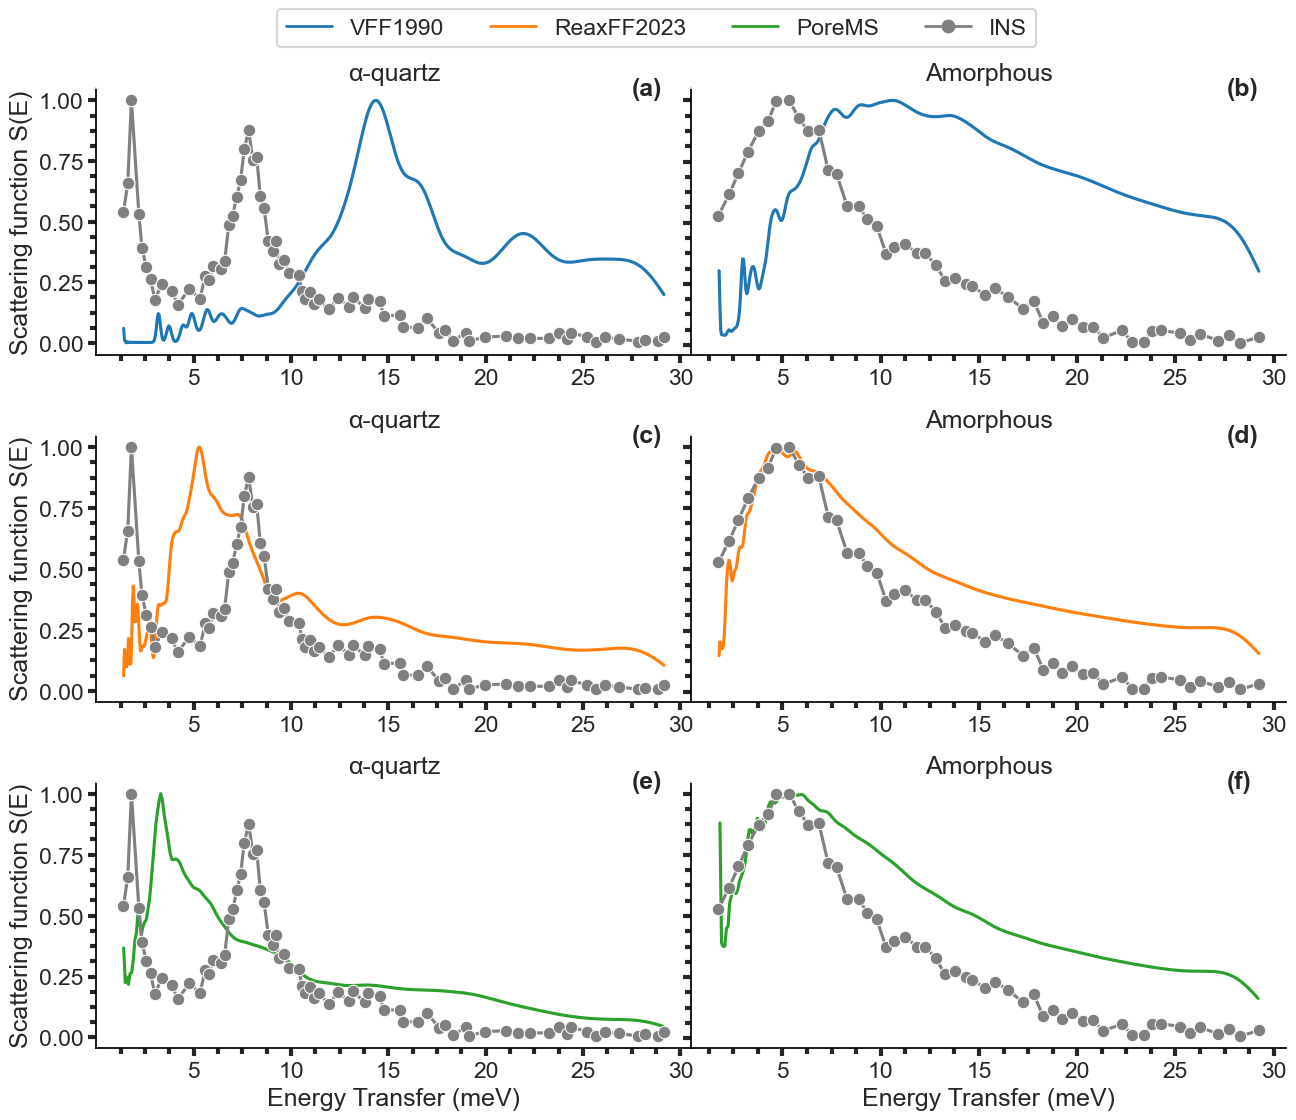

In [11]:
fig, axs = plt.subplots(ncols=2,nrows=3,figsize=(7*2,4*3))
sns.set_context("talk")
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
emin,emax=1,30
index=["(%s)"%x for x in list("abcdef")]

force_fields=df_dos_md["Force Field"].unique()
for i, sys in enumerate(df_dos_md["System"].unique()):
    for j,force_field in enumerate(force_fields):
        ax=axs[j,i]
        ax.text(labx, laby, index[2*j+i],weight='bold' ,transform=ax.transAxes)

        sns.lineplot(data=df_dos_md.query("Weight== 'Incoherent' and %f < `Energy Transfer (meV)` and `Energy Transfer (meV)` < %f and System == '%s' and `S(E)` > 0 and `Temperature (K)` == 300 and `Force Field` == '%s'"%(emin,emax,sys,force_field))
                    ,y="S(E)"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                   ,color=palette[j]
               )

        sns.lineplot(data=df_experiment.query("System == '%s'"%sys)
            ,y="S(E)"
            ,x='Energy Transfer (meV)'
            ,ax=ax
           ,color="grey"
            ,marker="o"
       )

        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(which='both',direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.set_ylabel("Scattering function S(E)")
        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))

        if i > 0:
            ax.set_ylabel("")
            ax.set_yticklabels([])
        if j < len(force_fields)-1:
            ax.set_xlabel("")
            
        ax.set_title(sys,y=1)
            
custom_lines = [Line2D([0], [0], color=palette[0], lw=2)
                ,Line2D([0], [0], color=palette[1], lw=2)
                ,Line2D([0], [0], color=palette[2], lw=2)
                ,Line2D([0], [0], color="grey", lw=2,marker="o")
               ]
ax.legend(custom_lines,list(force_fields)+["INS"])
sns.move_legend(ax,'center',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)


            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0., 
                    hspace=0.3
                   )

plt.savefig("../figures/fig4.pdf", pad_inches=0.2,bbox_inches="tight")